In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import xml.etree.ElementTree as ET

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [3]:
DATA_ROOT = Path(r"C:\Users\hp\mona(smartpark)\first dataset")
XML_PATH = DATA_ROOT / "annotations.xml"

In [4]:

CLASS_NAMES = ["free_parking_space", "not_free_parking_space", "partially_free_parking_space"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}

In [5]:
def parse_cvat_xml(xml_path: Path):
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    samples = []
    img_to_size = {}
    for img in root.findall("image"):
        img_name = img.attrib["name"]
        w = int(float(img.attrib.get("width", "0")))
        h = int(float(img.attrib.get("height", "0")))
        img_to_size[img_name] = (w, h)
        for poly in img.findall("polygon"):
            label = poly.attrib.get("label")
            if label not in CLASS_TO_ID:
                continue
            pts = poly.attrib.get("points", "")
            coords = []
            for p in pts.split(";"):
                if not p.strip():
                    continue
                x_str, y_str = p.split(",")
                coords.append((float(x_str), float(y_str)))
            if len(coords) < 2:
                continue
            xs = [c[0] for c in coords]
            ys = [c[1] for c in coords]
            x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
            samples.append({
                "img_rel": img_name,
                "bbox": (x1, y1, x2, y2),
                "label_id": CLASS_TO_ID[label]
            })
    return samples, img_to_size


In [6]:
samples, _ = parse_cvat_xml(XML_PATH)

img_has_partial = {}
for s in samples:
    img_has_partial.setdefault(s["img_rel"], 0)
for s in samples:
    if s["label_id"] == CLASS_TO_ID["partially_free_parking_space"]:
        img_has_partial[s["img_rel"]] = 1


In [7]:

all_images = sorted(list({s["img_rel"] for s in samples}))
rare_images = [img for img in all_images if img_has_partial.get(img, 0) == 1]
other_images = [img for img in all_images if img_has_partial.get(img, 0) == 0]

In [8]:
rng = random.Random(SEED)
rng.shuffle(rare_images)
rng.shuffle(other_images)

n_images = len(all_images)
n_test = max(1, int(round(0.15 * n_images)))
n_val = max(1, int(round(0.15 * n_images)))
n_train = n_images - n_test - n_val

test_imgs = set()
val_imgs = set()
train_imgs = set()


In [9]:

if len(rare_images) >= 1:
    test_imgs.add(rare_images[0])
if len(rare_images) >= 2:
    val_imgs.add(rare_images[1])
for r in rare_images[2:]:
    train_imgs.add(r)

In [10]:
def fill_sets(others, train_set, val_set, test_set, n_train, n_val, n_test):
    for img in others:
        if len(test_set) < n_test:
            test_set.add(img)
        elif len(val_set) < n_val:
            val_set.add(img)
        else:
            train_set.add(img)
    while len(train_set) < n_train and (len(val_set) > n_val):
        train_set.add(val_set.pop())
    while len(train_set) < n_train and (len(test_set) > n_test):
        train_set.add(test_set.pop())
    return train_set, val_set, test_set

In [11]:
train_imgs, val_imgs, test_imgs = fill_sets(other_images, train_imgs, val_imgs, test_imgs, n_train, n_val, n_test)


In [12]:
def filter_by_images(samples, img_set):
    return [s for s in samples if s["img_rel"] in img_set]


In [13]:
train_samples = filter_by_images(samples, train_imgs)
val_samples = filter_by_images(samples, val_imgs)
test_samples = filter_by_images(samples, test_imgs)


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [15]:

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)], p=0.7),
    transforms.RandomApply([transforms.RandomAffine(degrees=6, translate=(0.03, 0.03), scale=(0.95, 1.05))], p=0.6),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=EfficientNet_V2_S_Weights.IMAGENET1K_V1.transforms().mean,
                         std=EfficientNet_V2_S_Weights.IMAGENET1K_V1.transforms().std),
])


In [16]:

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=EfficientNet_V2_S_Weights.IMAGENET1K_V1.transforms().mean,
                         std=EfficientNet_V2_S_Weights.IMAGENET1K_V1.transforms().std),
])


In [17]:
class ParkingSlotCropDataset(Dataset):
    def __init__(self, root: Path, samples, transform=None, pad_ratio=0.06):
        self.root = root
        self.samples = samples
        self.transform = transform
        self.pad_ratio = pad_ratio

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img_path = self.root / s["img_rel"]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        x1, y1, x2, y2 = s["bbox"]
        bw = max(1.0, x2 - x1)
        bh = max(1.0, y2 - y1)
        pad = self.pad_ratio * max(bw, bh)

        x1p = int(max(0, np.floor(x1 - pad)))
        y1p = int(max(0, np.floor(y1 - pad)))
        x2p = int(min(W - 1, np.ceil(x2 + pad)))
        y2p = int(min(H - 1, np.ceil(y2 + pad)))

        if x2p <= x1p:
            x2p = min(W - 1, x1p + 1)
        if y2p <= y1p:
            y2p = min(H - 1, y1p + 1)

        crop = img.crop((x1p, y1p, x2p, y2p))
        y = int(s["label_id"])
        if self.transform:
            crop = self.transform(crop)
        return crop, y

In [18]:

train_ds = ParkingSlotCropDataset(DATA_ROOT, train_samples, transform=train_tf)
val_ds = ParkingSlotCropDataset(DATA_ROOT, val_samples, transform=eval_tf)
test_ds = ParkingSlotCropDataset(DATA_ROOT, test_samples, transform=eval_tf)

In [19]:

y_train = np.array([s["label_id"] for s in train_samples], dtype=np.int64)
class_counts = np.bincount(y_train, minlength=len(CLASS_NAMES))
class_weights = (class_counts.sum() / np.maximum(class_counts, 1)).astype(np.float32)
class_weights = class_weights / class_weights.mean()
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

In [20]:
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights, dtype=torch.double),
                                num_samples=len(sample_weights),
                                replacement=True)

In [21]:

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


In [22]:
weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
model = efficientnet_v2_s(weights=weights)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(CLASS_NAMES))
model = model.to(device)

In [23]:
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=18)


In [24]:
def run_eval(model, loader):
    model.eval()
    ys = []
    ps = []
    probs = []
    total = 0
    correct = 0
    loss_sum = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss_sum += float(loss.item()) * yb.size(0)

            pr = torch.argmax(logits, dim=1)
            total += yb.size(0)
            correct += int((pr == yb).sum().item())

            ys.append(yb.detach().cpu().numpy())
            ps.append(pr.detach().cpu().numpy())
            probs.append(torch.softmax(logits, dim=1).detach().cpu().numpy())

    y_true = np.concatenate(ys) if ys else np.array([])
    y_pred = np.concatenate(ps) if ps else np.array([])
    y_prob = np.concatenate(probs) if probs else np.array([])
    acc = correct / max(1, total)
    avg_loss = loss_sum / max(1, total)
    return avg_loss, acc, y_true, y_pred, y_prob


In [25]:
EPOCHS = 18
best_val_acc = -1.0
best_state = None

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

In [26]:
for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0
    correct = 0
    loss_sum = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        loss_sum += float(loss.item()) * yb.size(0)
        pr = torch.argmax(logits, dim=1)
        total += yb.size(0)
        correct += int((pr == yb).sum().item())

    scheduler.step()

    train_loss = loss_sum / max(1, total)
    train_acc = correct / max(1, total)

    val_loss, val_acc, _, _, _ = run_eval(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc*100:.2f}% | val_loss={val_loss:.4f} val_acc={val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


Epoch 01/18 | train_loss=0.2797 train_acc=68.10% | val_loss=0.9376 val_acc=86.63%
Epoch 02/18 | train_loss=0.0143 train_acc=94.71% | val_loss=1.1348 val_acc=93.60%
Epoch 03/18 | train_loss=0.0054 train_acc=98.35% | val_loss=1.5704 val_acc=94.77%
Epoch 04/18 | train_loss=0.0027 train_acc=99.34% | val_loss=1.4324 val_acc=95.35%
Epoch 05/18 | train_loss=0.0017 train_acc=99.34% | val_loss=1.4640 val_acc=95.93%
Epoch 06/18 | train_loss=0.0009 train_acc=99.83% | val_loss=1.4556 val_acc=95.93%
Epoch 07/18 | train_loss=0.0007 train_acc=99.83% | val_loss=1.5620 val_acc=95.93%
Epoch 08/18 | train_loss=0.0010 train_acc=99.34% | val_loss=1.5339 val_acc=95.93%
Epoch 09/18 | train_loss=0.0010 train_acc=99.34% | val_loss=1.5692 val_acc=93.60%
Epoch 10/18 | train_loss=0.0008 train_acc=99.67% | val_loss=1.6116 val_acc=93.60%
Epoch 11/18 | train_loss=0.0007 train_acc=99.67% | val_loss=1.6170 val_acc=94.77%
Epoch 12/18 | train_loss=0.0011 train_acc=99.67% | val_loss=1.5039 val_acc=95.93%
Epoch 13/18 | tr

In [27]:
model.load_state_dict(best_state)

<All keys matched successfully>

In [28]:
test_loss, test_acc, y_true, y_pred, y_prob = run_eval(model, test_loader)
print("\n=== TEST RESULTS ===")
print(f"test_loss={test_loss:.4f} | test_acc={test_acc*100:.2f}%")


=== TEST RESULTS ===
test_loss=0.9388 | test_acc=97.62%


In [58]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
print("\n=== CONFUSION MATRIX (rows=true, cols=pred) ===")
print(cm)


=== CONFUSION MATRIX (rows=true, cols=pred) ===
[[47  0  0]
 [ 2 76  0]
 [ 1  0  0]]


In [60]:
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))



=== CLASSIFICATION REPORT ===
                              precision    recall  f1-score   support

          free_parking_space     0.9400    1.0000    0.9691        47
      not_free_parking_space     1.0000    0.9744    0.9870        78
partially_free_parking_space     0.0000    0.0000    0.0000         1

                    accuracy                         0.9762       126
                   macro avg     0.6467    0.6581    0.6520       126
                weighted avg     0.9697    0.9762    0.9725       126



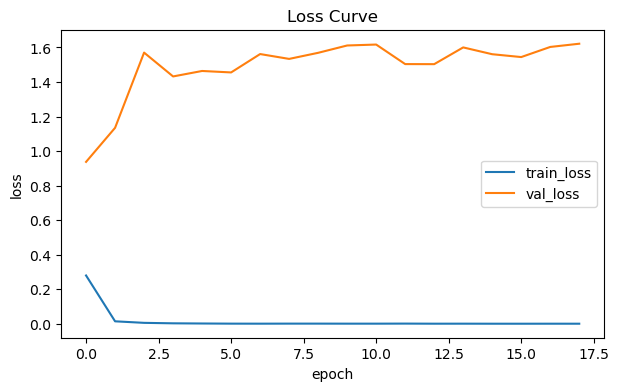

In [62]:
plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss Curve")
plt.legend()
plt.show()


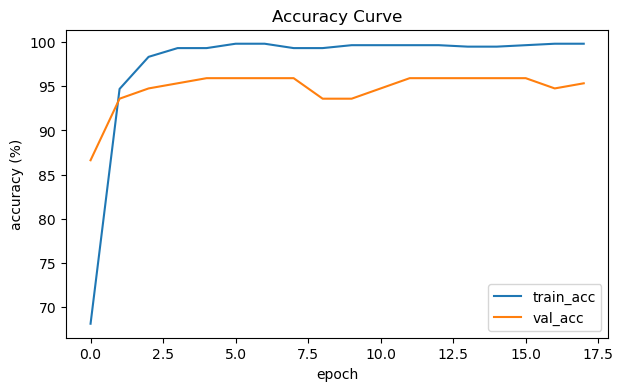

In [64]:
plt.figure(figsize=(7,4))
plt.plot(np.array(history["train_acc"])*100, label="train_acc")
plt.plot(np.array(history["val_acc"])*100, label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.show()


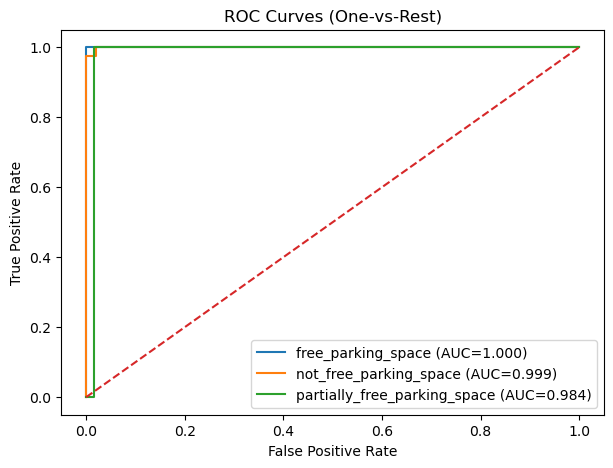

In [66]:
y_true_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))
plt.figure(figsize=(7,5))
for i, cname in enumerate(CLASS_NAMES):
    if y_true_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

In [68]:
def show_predictions_grid(model, dataset, n=18):
    model.eval()
    n = min(n, len(dataset))
    idxs = rng.sample(range(len(dataset)), n)
    cols = 6
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(18, 3*rows))
    with torch.no_grad():
        for k, idx in enumerate(idxs, start=1):
            x, y = dataset[idx]
            logits = model(x.unsqueeze(0).to(device))
            prob = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred = int(np.argmax(prob))
            img = x.clone()
            mean = torch.tensor(EfficientNet_V2_S_Weights.IMAGENET1K_V1.transforms().mean).view(3,1,1)
            std = torch.tensor(EfficientNet_V2_S_Weights.IMAGENET1K_V1.transforms().std).view(3,1,1)
            img = (img * std + mean).clamp(0,1)
            img_np = img.permute(1,2,0).numpy()

            plt.subplot(rows, cols, k)
            plt.imshow(img_np)
            plt.axis("off")
            plt.title(f"T:{CLASS_NAMES[y]}\nP:{CLASS_NAMES[pred]} ({prob[pred]*100:.1f}%)")
    plt.tight_layout()
    plt.show()


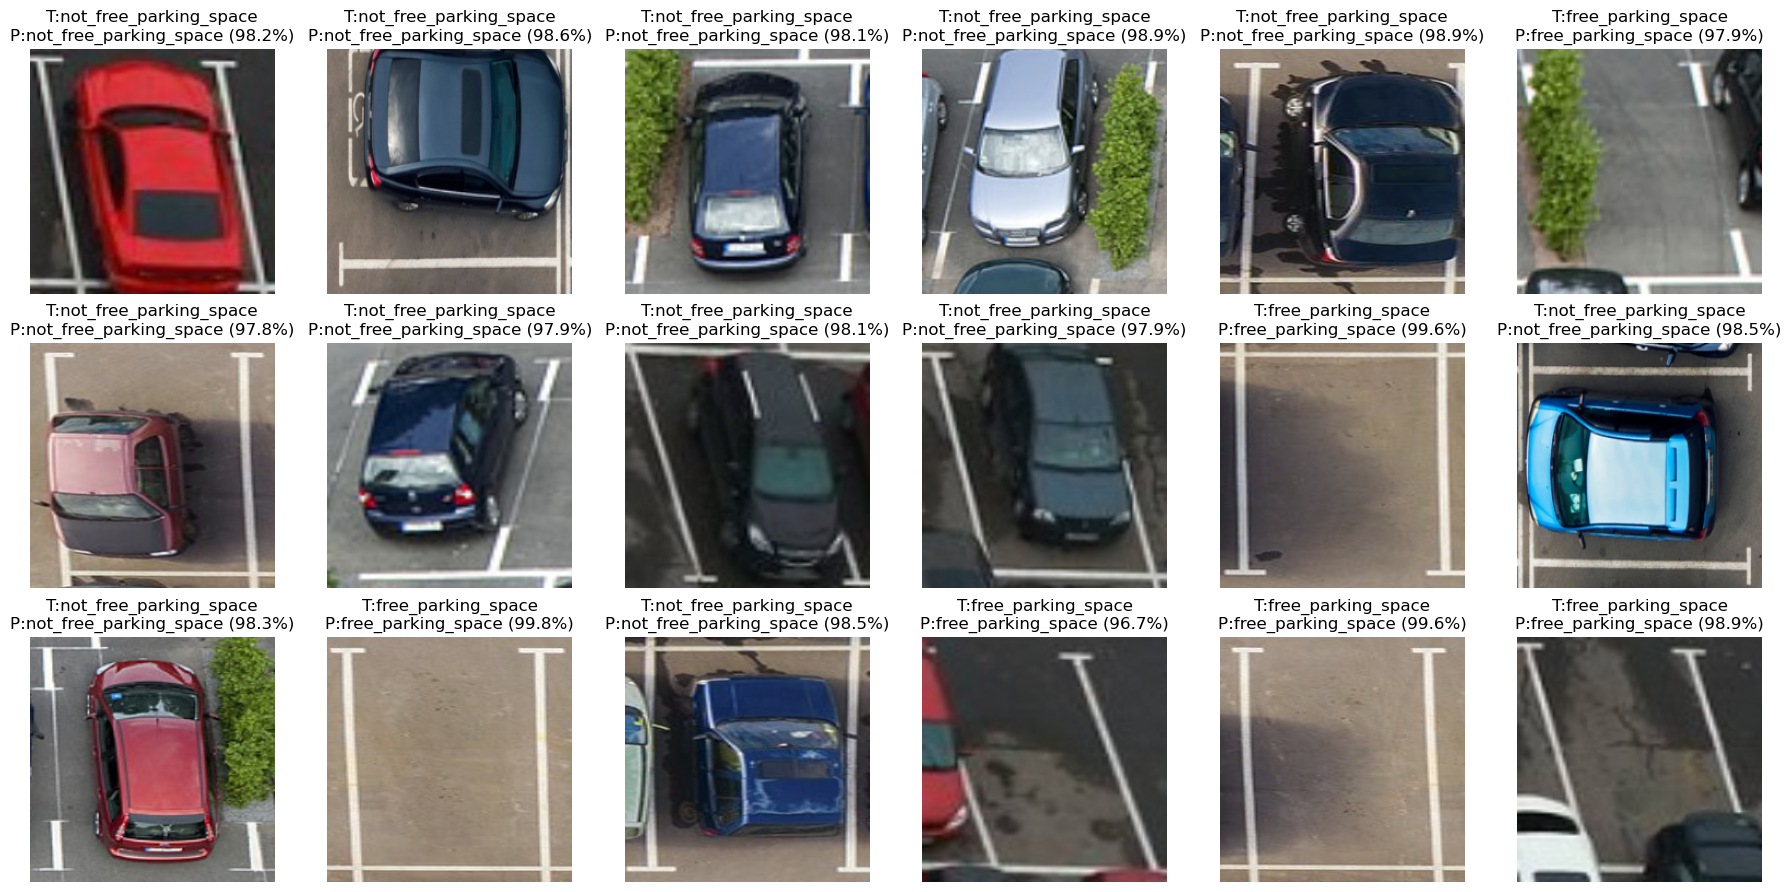

In [70]:
show_predictions_grid(model, test_ds, n=18)

In [72]:
SAVE_MODEL = True
if SAVE_MODEL:
    out_path = DATA_ROOT / "parking_slot_classifier_efficientnetv2s.pt"
    torch.save({
        "model_state": model.state_dict(),
        "class_names": CLASS_NAMES,
        "seed": SEED
    }, out_path)
    print(f"\nSaved model to: {out_path}")


Saved model to: C:\Users\hp\mona(smartpark)\first dataset\parking_slot_classifier_efficientnetv2s.pt
